In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# 1. Load your cleaned files
liver_df = pd.read_csv('/Users/ishaanjain/DL PROJECT/data_processed/ilpd_cleaned.csv')
diabetes_df = pd.read_csv('/Users/ishaanjain/DL PROJECT/data_processed/diabetes_cleaned_dataset.csv')
liver_df

,age,gender,total_bilirubin,direct_bilirubin,alkaline_phosphotase,alt,ast,total_proteins,albumin,albumin_globulin_ratio,liver_disease
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [3]:
# 2. Training Liver Model
X_l = liver_df.drop('liver_disease', axis=1)
y_l = liver_df['liver_disease']
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_l, y_l, test_size=0.2, random_state=42)


model_liver_v2 = RandomForestClassifier(
    n_estimators=150, 
    max_depth=7,        
    min_samples_leaf=5,  
    random_state=42
)

model_liver_v2.fit(X_train_l, y_train_l)

RandomForestClassifier(max_depth=7, min_samples_leaf=5, n_estimators=150,
                       random_state=42)

In [4]:
# 3. Train Diabetes Model
X_d = diabetes_df.drop('Diabetic', axis=1)
y_d = diabetes_df['Diabetic']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

In [5]:
model_diabetes = RandomForestClassifier(n_estimators=100, random_state=42)
model_diabetes.fit(X_train_d, y_train_d)

RandomForestClassifier(random_state=42)

In [6]:
print(f"Liver Model Accuracy: {accuracy_score(y_test_l, model_liver_v2.predict(X_test_l))*100:.2f}%")
print(f"Diabetes Model Accuracy: {accuracy_score(y_test_d, model_diabetes.predict(X_test_d))*100:.2f}%")

Liver Model Accuracy: 72.65%
Diabetes Model Accuracy: 95.79%


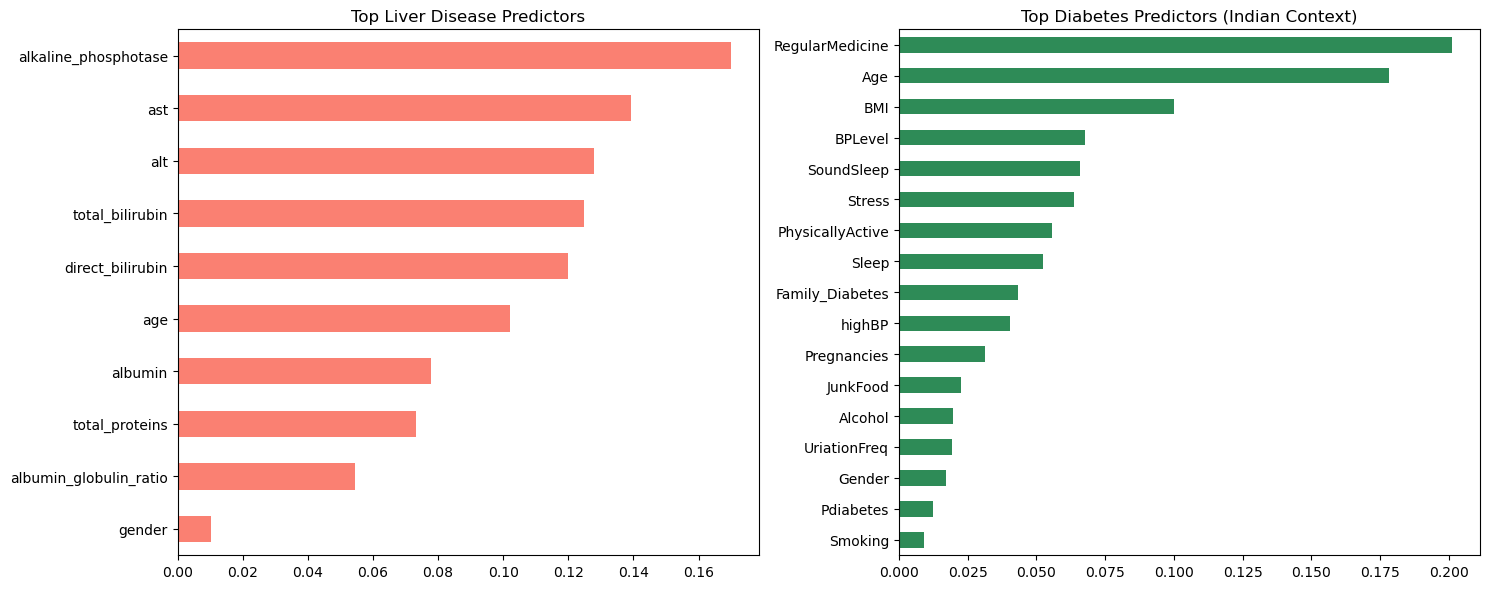

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Plot 1: Liver Importance
plt.subplot(1, 2, 1)
feat_l = pd.Series(model_liver_v2.feature_importances_, index=X_l.columns).sort_values()
feat_l.plot(kind='barh', color='salmon')
plt.title('Top Liver Disease Predictors')

# Plot 2: Diabetes Importance
plt.subplot(1, 2, 2)
feat_d = pd.Series(model_diabetes.feature_importances_, index=X_d.columns).sort_values()
feat_d.plot(kind='barh', color='seagreen')
plt.title('Top Diabetes Predictors (Indian Context)')

plt.tight_layout()
plt.show()

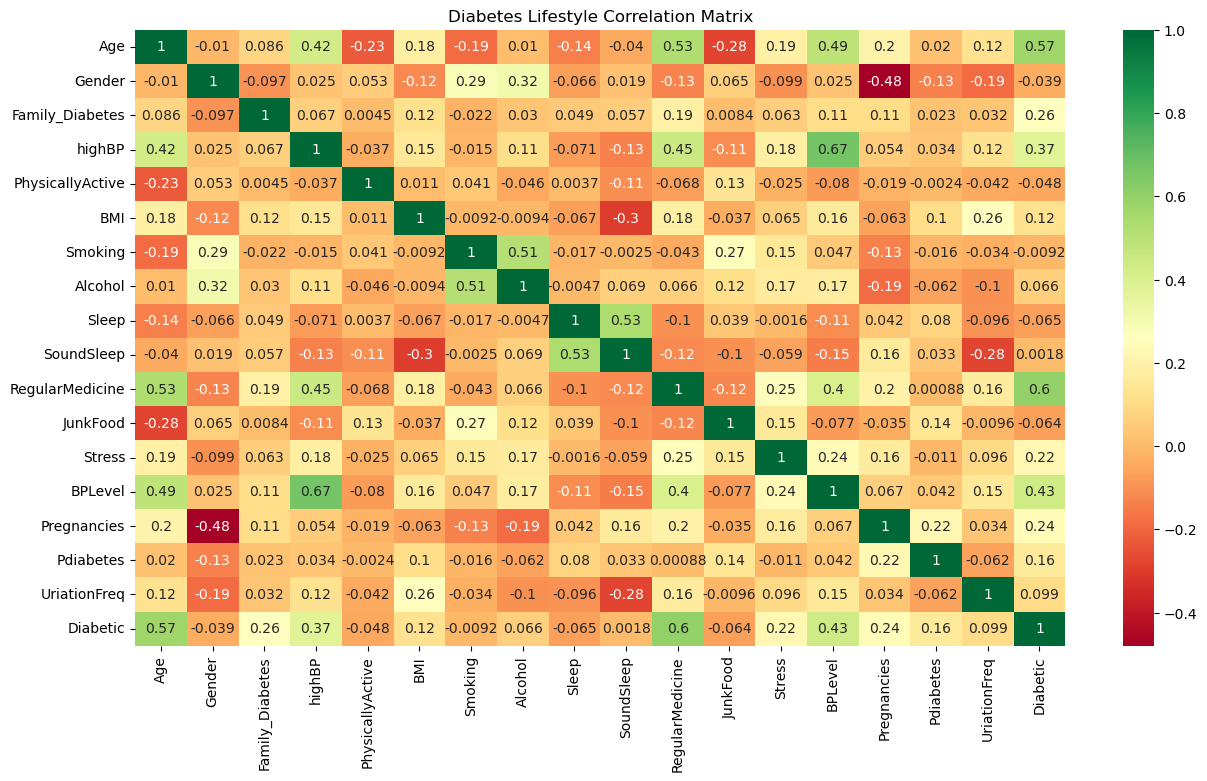

In [8]:
plt.figure(figsize=(15, 8))
sns.heatmap(diabetes_df.corr(), annot=True, cmap='RdYlGn')
plt.title('Diabetes Lifestyle Correlation Matrix')
plt.show()

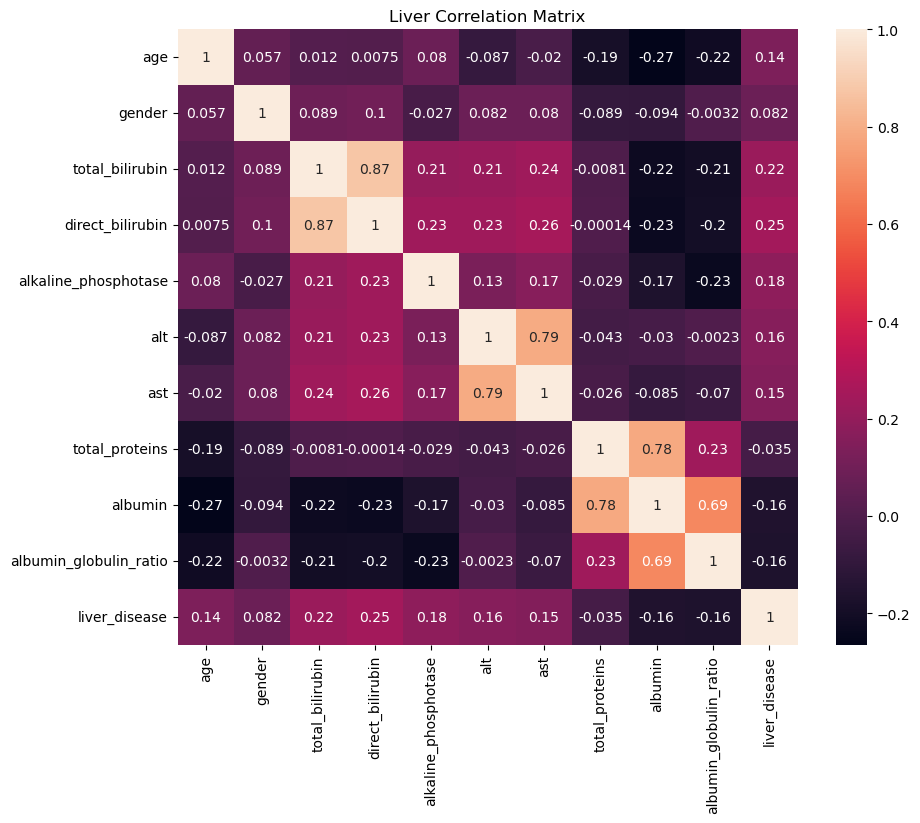

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(liver_df.corr(), annot=True)
plt.title('Liver Correlation Matrix')
plt.show()

<Figure size 600x500 with 0 Axes>

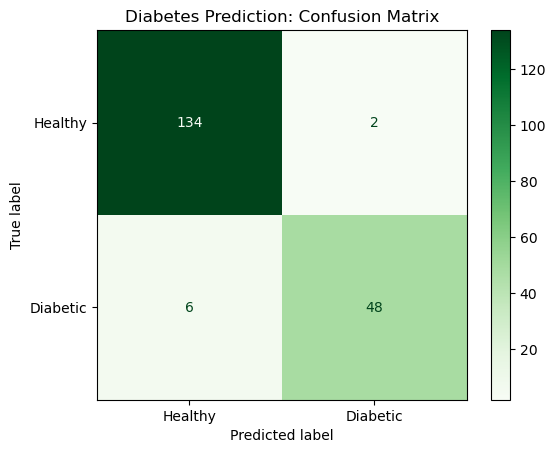

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate Confusion Matrix for Diabetes
cm_d = confusion_matrix(y_test_d, model_diabetes.predict(X_test_d))
disp_d = ConfusionMatrixDisplay(confusion_matrix=cm_d, display_labels=['Healthy', 'Diabetic'])

# Plot
plt.figure(figsize=(6, 5))
disp_d.plot(cmap='Greens')
plt.title('Diabetes Prediction: Confusion Matrix')
plt.show()

In [11]:
from sklearn.model_selection import cross_val_score

def check_memorization(model, X, y, model_name):
    # Perform 5-Fold Cross Validation
    scores = cross_val_score(model, X, y, cv=5)
    
    print(f"--- {model_name} Stability Audit ---")
    print(f"Individual Fold Accuracies: {scores}")
    print(f"Mean Accuracy: {scores.mean()*100:.2f}%")
    print(f"Standard Deviation (Variance): {scores.std()*100:.2f}%")
    
    if scores.std() > 0.05:
        print("Result: High Variance. Model might be memorizing noise.")
    else:
        print("Result: Stable Performance. Model has learned patterns.")
    print("-" * 30)

# Check both models
check_memorization(model_liver_v2, X_l, y_l, "Liver Model")
check_memorization(model_diabetes, X_d, y_d, "Diabetes Model")

--- Liver Model Stability Audit ---
Individual Fold Accuracies: [0.67521368 0.75213675 0.72649573 0.62068966 0.72413793]
Mean Accuracy: 69.97%
Standard Deviation (Variance): 4.67%
Result: Stable Performance. Model has learned patterns.
------------------------------
--- Diabetes Model Stability Audit ---
Individual Fold Accuracies: [0.97368421 0.93684211 0.95789474 0.96842105 0.98421053]
Mean Accuracy: 96.42%
Standard Deviation (Variance): 1.61%
Result: Stable Performance. Model has learned patterns.
------------------------------


In [12]:
import joblib

joblib.dump(model_liver_v2, "liver_model.pkl")
joblib.dump(model_diabetes, "diabetes_model.pkl")


['diabetes_model.pkl']